# Fase 4b — Modelado: CNN pequeña desde cero

CNN de 3 bloques convolucionales (Conv-BN-ReLU + MaxPool) + cabeza densa, entrenada **desde cero** sobre imágenes 128×128, con **class_weight** y **data augmentation** (capas dentro del modelo).

> Conclusiones en `reports/04_modelado.md`. El modelo se guarda en `artifacts/cnn.keras` para la Fase 5.

## 0. Configuración

In [1]:
import sys, time
from pathlib import Path
root = Path.cwd()
while not (root / 'src').exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras

from src.data.dataset import build_index, QUALITY_ORDER
from src.data import preprocess as pp
from src.models.cnn import build_cnn
from src.evaluation.metrics import evaluate, plot_confusion, summary_row

sns.set_theme(style='whitegrid')
np.random.seed(42); tf.random.set_seed(42)
ART = root / 'artifacts'; ART.mkdir(exist_ok=True)
print('TensorFlow', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow 2.17.1
GPUs: []


## 1. Cargar imágenes en memoria (train/val) + etiquetas

In [2]:
df = pp.make_splits(pp.clean_index(build_index()))
label2idx = {q: i for i, q in enumerate(QUALITY_ORDER)}

t0 = time.time()
Xtr, ytr = pp.load_images_uint8(df[df.split=='train'])
Xva, yva = pp.load_images_uint8(df[df.split=='val'])
print(f'Imágenes cargadas en {time.time()-t0:.0f}s')
ytr_i = np.array([label2idx[q] for q in ytr])
yva_i = np.array([label2idx[q] for q in yva])
print('X_train:', Xtr.shape, Xtr.dtype, '| X_val:', Xva.shape)

  cargadas 1000/5461 imágenes...


  cargadas 2000/5461 imágenes...


  cargadas 3000/5461 imágenes...


  cargadas 4000/5461 imágenes...


  cargadas 5000/5461 imágenes...


  cargadas 1000/1171 imágenes...


Imágenes cargadas en 341s
X_train: (5461, 128, 128, 3) uint8 | X_val: (1171, 128, 128, 3)


## 2. Datasets tf.data y pesos de clase

In [3]:
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE
train_ds = (tf.data.Dataset.from_tensor_slices((Xtr, ytr_i))
            .shuffle(2048, seed=42).batch(BATCH).prefetch(AUTOTUNE))
val_ds = (tf.data.Dataset.from_tensor_slices((Xva, yva_i))
          .batch(BATCH).prefetch(AUTOTUNE))

cw = pp.class_weights(df[df.split=='train']['quality'])
class_weight = {label2idx[k]: v for k, v in cw.items()}
print('class_weight (por índice):', {k: round(v,3) for k,v in class_weight.items()})

class_weight (por índice): {0: 1.466, 1: 0.772, 2: 0.978}


## 3. Construcción y compilación de la CNN

In [4]:
model = build_cnn(input_shape=(128,128,3), n_classes=len(QUALITY_ORDER), augment=True)
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "cnn_calidad_frutas"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,819 (432.89 KB)

 Trainable params: 110,371 (431.14 KB)

 Non-trainable params: 448 (1.75 KB)

## 4. Entrenamiento (con EarlyStopping)

In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                  restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=3, min_lr=1e-5),
]
t0 = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=30,
                    class_weight=class_weight, callbacks=callbacks, verbose=2)
print(f'Entrenamiento en {time.time()-t0:.0f}s ({len(history.history["loss"])} épocas)')
model.save(ART / 'cnn.keras')
print('Modelo guardado en artifacts/cnn.keras')

Epoch 1/30


171/171 - 36s - 209ms/step - accuracy: 0.8162 - loss: 0.5062 - val_accuracy: 0.6943 - val_loss: 1.2539 - learning_rate: 0.0010


Epoch 2/30


171/171 - 33s - 192ms/step - accuracy: 0.8335 - loss: 0.4745 - val_accuracy: 0.6507 - val_loss: 1.6915 - learning_rate: 0.0010


Epoch 3/30


...

Epoch 23/30


171/171 - 26s - 151ms/step - accuracy: 0.9013 - loss: 0.2616 - val_accuracy: 0.9436 - val_loss: 0.1590 - learning_rate: 6.2500e-05


Epoch 24/30


171/171 - 26s - 153ms/step - accuracy: 0.9053 - loss: 0.2631 - val_accuracy: 0.9044 - val_loss: 0.2490 - learning_rate: 6.2500e-05


Entrenamiento en 726s (24 épocas)
Modelo guardado en artifacts/cnn.keras


## 5. Curvas de entrenamiento

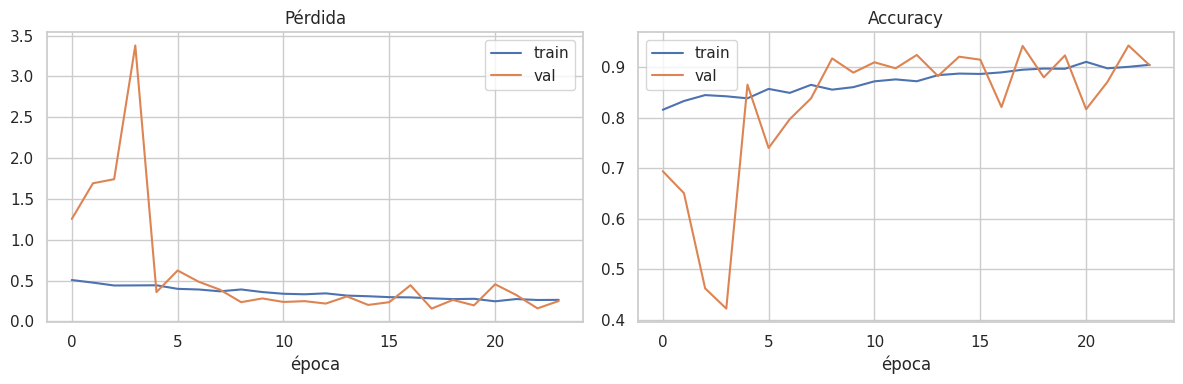

In [6]:
h = history.history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h['loss'], label='train'); axes[0].plot(h['val_loss'], label='val')
axes[0].set_title('Pérdida'); axes[0].set_xlabel('época'); axes[0].legend()
axes[1].plot(h['accuracy'], label='train'); axes[1].plot(h['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('época'); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Métricas en validación

{'modelo': 'CNN', 'macro_f1': 0.9367, 'balanced_acc': 0.9373, 'recall_Bad': 0.8872}


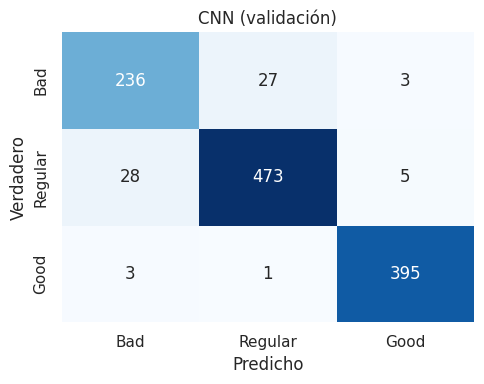

              precision    recall  f1-score   support

         Bad       0.88      0.89      0.89       266
     Regular       0.94      0.93      0.94       506
        Good       0.98      0.99      0.99       399

    accuracy                           0.94      1171
   macro avg       0.94      0.94      0.94      1171
weighted avg       0.94      0.94      0.94      1171



In [7]:
proba = model.predict(val_ds, verbose=0)
pred_idx = proba.argmax(axis=1)
yva_pred = np.array([QUALITY_ORDER[i] for i in pred_idx])
print(summary_row('CNN', yva, yva_pred))

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(yva, yva_pred, ax, 'CNN (validación)')
plt.tight_layout(); plt.show()

from sklearn.metrics import classification_report
print(classification_report(yva, yva_pred, labels=QUALITY_ORDER, zero_division=0))